# Imports

In [1]:
import pandas as pd
"""
Lightweight EDA helpers for raw exploratory analysis.
Dependencies: pandas, numpy, matplotlib, seaborn (optional), plotly, sklearn, wordcloud
"""
from collections import Counter
import logging
import numpy as np
import matplotlib.pyplot as plt
try:
    import seaborn as sns
except Exception:
    sns = None
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from sklearn.metrics import confusion_matrix
from typing import List, Optional
from wordcloud import WordCloud

logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)


# Functions

In [2]:
def summarize_df(df: pd.DataFrame) -> pd.DataFrame:
    """Return summary: dtype, non-null count, missing pct, unique, sample values."""
    s = pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "non_null": df.notna().sum(),
        "missing_pct": (df.isna().mean() * 100).round(2),
        "unique": df.nunique(dropna=False)
    })
    s["sample_values"] = [df[col].dropna().unique()[:5].tolist() for col in df.columns]
    return s


def missing_report(df: pd.DataFrame, top_n: int = 20) -> pd.DataFrame:
    """Return top_n columns with highest missing percentage."""
    mr = (df.isna().mean() * 100).sort_values(ascending=False)
    return mr.head(top_n).to_frame("missing_pct")


def numeric_columns(df: pd.DataFrame) -> List[str]:
    return df.select_dtypes(include=[np.number]).columns.tolist()


def plot_distributions(df: pd.DataFrame, cols: Optional[List[str]] = None, bins: int = 30, figsize=(12, 8)):
    """Plot histograms for numeric columns (subset if cols provided)."""
    cols = cols or numeric_columns(df)
    n = len(cols)
    if n == 0:
        logger.info("No numeric columns to plot.")
        return
    ncols = min(3, n)
    nrows = (n + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    axes = np.array(axes).reshape(-1)
    for ax, col in zip(axes, cols):
        ax.hist(df[col].dropna(), bins=bins, color="#4C72B0")
        ax.set_title(col)
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


def plot_correlation_heatmap(df: pd.DataFrame, cols: Optional[List[str]] = None, method: str = "spearman", figsize=(10, 8)):
    """Plot correlation heatmap for numeric columns."""
    cols = cols or numeric_columns(df)
    if len(cols) < 2:
        logger.info("Need at least two numeric columns for correlation.")
        return
    corr = df[cols].corr(method=method)
    if sns:
        plt.figure(figsize=figsize)
        sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0)
        plt.title(f"{method} correlation")
        plt.show()
    else:
        plt.figure(figsize=figsize)
        plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
        plt.colorbar()
        plt.xticks(range(len(cols)), cols, rotation=90)
        plt.yticks(range(len(cols)), cols)
        plt.title(f"{method} correlation (seaborn not installed)")
        plt.show()

def plot_pairplot_sample(df: pd.DataFrame, cols: Optional[List[str]] = None, sample_frac: float = 0.2, max_cols: int = 6):
    """Quick pairplot for a sample of numeric columns (uses seaborn if available)."""
    cols = cols or numeric_columns(df)
    cols = cols[:max_cols]
    sample = df[cols].sample(frac=min(1.0, sample_frac), random_state=0)
    if sns:
        sns.pairplot(sample)
        plt.show()
    else:
        logger.info("seaborn not installed; skipping pairplot.")

def plot_pairplot_sample(df: pd.DataFrame, cols: Optional[List[str]] = None, sample_frac: float = 0.2, max_cols: int = 6, hue: Optional[str] = None):
    """Quick pairplot for a sample of numeric columns using plotly (interactive)."""
    cols = cols or numeric_columns(df)
    cols = cols[:max_cols]
    if len(cols) == 0:
        logger.info("No numeric columns to plot.")
        return
    # include hue column in sample if provided and present
    sample_cols = cols[:] 
    if hue and hue in df.columns and hue not in sample_cols:
        sample_cols.append(hue)
    sample = df[sample_cols].sample(frac=min(1.0, sample_frac), random_state=0)
    try:
        import plotly.express as px
    except Exception:
        logger.info("plotly not installed; skipping pairplot.")
        return
    if hue and hue in sample.columns:
        fig = px.scatter_matrix(sample, dimensions=cols, color=hue)
    else:
        fig = px.scatter_matrix(sample, dimensions=cols)
    # adjust layout for readability
    fig.update_layout(height=900, width=min(1200, 200 * len(cols)), title="Interactive Scatter Matrix")
    fig.show()

def detect_outliers_zscore(series: pd.Series, thresh: float = 3.0) -> pd.Series:
    """Return boolean mask where True indicates an outlier by z-score."""
    s = series.dropna()
    mean = s.mean()
    std = s.std()
    if std == 0 or np.isnan(std):
        return pd.Series(False, index=series.index)
    z = (series - mean).abs() / std
    return z > thresh

def plot_outliers(series: pd.Series, thresh: float = 3.0):
    """Plot a series with outliers highlighted."""
    outliers = detect_outliers_zscore(series, thresh)
    plt.figure(figsize=(10, 4))
    plt.plot(series.index, series.values, label="Data", color="#4C72B0")
    plt.scatter(series.index[outliers], series.values[outliers], color="#C44E52", label="Outliers")
    plt.title(f"Outlier Detection (z-score > {thresh})")
    plt.xlabel("Index")
    plt.ylabel(series.name)
    plt.legend()
    plt.show()

def encode_categorical_summary(df: pd.DataFrame, cat_cols: Optional[List[str]] = None, top_n: int = 10) -> pd.DataFrame:
    """Return frequency tables for categorical columns (top_n values)."""
    cat_cols = cat_cols or df.select_dtypes(include=["object", "category"]).columns.tolist()
    out = {}
    for c in cat_cols:
        out[c] = df[c].value_counts(dropna=False).head(top_n)
    # Convert to DataFrame with MultiIndex for easy inspection
    return pd.concat(out, axis=1)


def save_profile_report(df: pd.DataFrame, path: str = "pandas_profile_report.html"):
    """Save a pandas-profiling (ydata-profiling) report if available."""
    try:
        from ydata_profiling import ProfileReport
    except Exception:
        logger.error("ydata-profiling not installed. Install with: pip install ydata-profiling")
        return
    profile = ProfileReport(df, minimal=True)
    profile.to_file(path)
    logger.info("Saved profile report to %s", path)


def show_class_balance(
    df: pd.DataFrame, col: str = "recommended", top_n: Optional[int] = None
) -> None:
    """
    Show class counts, proportions, and a bar chart for any boolean or categorical column.

    Parameters
    ----------
    df : pd.DataFrame
        The dataframe containing the column.
    col : str
        The name of the column to analyze (default 'recommended').
    top_n : int, optional
        If set, show only the top_n most frequent categories (useful for high-cardinality columns).
    """
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not in dataframe.")
    class_counts = df[col].value_counts(dropna=False)
    if top_n is not None:
        class_counts = class_counts.head(top_n)
    print(f"Class balance for '{col}':")
    print(class_counts)
    class_proportions = (
        df[col].value_counts(normalize=True, dropna=False)
        .reindex(class_counts.index)
        .fillna(0)
    )
    print(f"\nClass proportions for '{col}':")
    print(class_proportions)
    plt.figure(figsize=(6, 4))
    class_counts.plot(kind="bar")
    plt.title(f"Class balance of '{col}'")
    plt.xlabel(col)
    plt.ylabel("Count")
    if len(class_counts) > 6:
        plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


def show_votes_helpful_distribution(
    df: pd.DataFrame,
    col: str = "votes_helpful",
    bins: int = 50,
    y_log: bool = True,
    x_max_percentile: Optional[float] = 99.5,
) -> None:
    """
    Show summary stats and distribution of a vote-like column (e.g. votes_helpful).

    Prints describe() and value_counts().head(10), then a histogram. Uses log scale
    on y by default so the typical spike at 0 and the long tail are both visible.
    Optionally caps x-axis at a percentile so the bulk of the distribution is visible.

    Parameters
    ----------
    df : pd.DataFrame
        The dataframe containing the column.
    col : str
        The name of the column (default 'votes_helpful').
    bins : int
        Number of histogram bins.
    y_log : bool
        If True, use log scale on y-axis.
    x_max_percentile : float, optional
        If set, limit x-axis to this percentile of the data (e.g. 99.5) to reduce
        distortion from extreme outliers.
    """
    if col not in df.columns:
        raise ValueError(f"Column '{col}' not in dataframe.")
    series = df[col].dropna()
    print(f"Summary for '{col}':")
    print(series.describe())
    print(f"\nTop value counts:")
    print(series.value_counts().head(10))
    plt.figure(figsize=(8, 4))
    to_plot = series
    if x_max_percentile is not None:
        cap = np.nanpercentile(series, x_max_percentile)
        to_plot = series.clip(upper=cap)
    plt.hist(to_plot, bins=bins, color="#4C72B0", edgecolor="white", alpha=0.8)
    if y_log:
        plt.yscale("log")
    plt.title(f"Distribution of '{col}'" + (f" (x capped at p{x_max_percentile})" if x_max_percentile else ""))
    plt.xlabel(col)
    plt.ylabel("Count" + (" (log)" if y_log else ""))
    plt.tight_layout()
    plt.show()

# Load Data

In [3]:
df_sample = pd.read_csv("../../data/raw/steam_reviews_full.csv", nrows=1_000_000)

In [4]:
df_sample['language'].value_counts()

language
english       392312
russian       185744
schinese      125667
brazilian      45571
turkish        44407
spanish        42013
polish         31777
german         31066
french         26499
koreana        21153
tchinese        8131
czech           7633
italian         5737
portuguese      4249
latam           4034
hungarian       3403
thai            3148
swedish         2676
finnish         2522
danish          2352
dutch           2335
japanese        2113
ukrainian       1820
norwegian       1185
romanian        1068
greek            598
bulgarian        481
vietnamese       306
Name: count, dtype: int64

In [5]:
df_eng = df_sample[df_sample['language']=='english']

In [6]:
pd.set_option("display.max_rows", 1000)
pd.set_option("display.max_columns", None)

# EDA 3: Text


## 3.3 Text Stats

In [7]:
pd.set_option('display.max_colwidth', None)
temp = df_eng.copy()
top_votes = temp.sort_values("votes_helpful", ascending=False).head(10)
display(top_votes[['review_id', 'votes_helpful', 'review']])
pd.set_option('display.max_colwidth', 100)


,review_id,votes_helpful,review
378171,32479482,7352,"The Witcher 3: Wild Hunt review\n\nMonsters? ✔\nPeople who are worse than monsters? ✔\nNaked girls? ✔\nMore naked girls? ✔\nEven more naked girls? ✔\nNude scenes? ✔\nSuperb voice acting? ✔\nMind-blowingly good storyline? ✔\nAn amazing 1st DLC, worth every penny? ✔\nAn even better 2nd DLC? ✔\n5 Gigantic open world areas? ✔ (Sorry Skyrim Skellige alone is as big as you) \nBeautiful environment? ✔\nNew Game +? ✔\nNo micro transactions? ✔\nUbisoft? Hell no m8's\nIn depth & amazing characters? ✔\nUnbelievably good atmosphere? ✔\nSoundtrack that is beyond awesome? ✔\nBase game GOTY 2015 + Blood and Wine GOTY 2016? ✔\n800 awards? ✔ Sorry every other game ever made \nPrevented Fallout 4 getting GOTY? ✔\nNot a single bad thing to say? ✔\nRIP social life? ✔\n\nCons:\nNo NG ++\n\nI have never played a game quite like The Witcher 3. You literally feel like you are Geralt, and you become connected to all the characters asif they really were your family.\n\n\nSummary:\n\nI would highly recommend The Witcher 3 to any RPG/mass content hungry gamers, it is a masterpiece.\n \n\n\nGame devs take note, CD Projekt Red actually make finished uncut games, plus DLC'S.\n\n500/10 would Witcher again\n\nYEN PLZ MOAR I LUV U"
381212,32034007,4685,"This game made me so miserable . \nThe writing can be as funny as heartbreaking \nThe Voice acting is one of the greatest i've ever heard \nA lot of the time , the many side quest were as awesome or even better than the main story (That is already amazing )\n\nPro : The whole game \nCon : Absolutely nothing \n\nIt's one of the greatest gaming experience I've ever had in my 24 years on this earth."
198110,60407763,4266,Toss a coin to your witcher
662605,26954647,3455,"Nominate this for ""GAME THAT DESERVES A SEQUEL""\n\nedit: Awards will be announced in December some time. Good job everyone!"
812983,32344224,2924,"The first Portal had genius, original gameplay mechanics, great story, great level progression, great voice acting, great characters, great engine and such a nice british humour it originated a ton of memes.\nIf you didn't play, finish and love Portal 1, you are a bad person.\n\nThis sequel brings all those qualities to a new level: _the story is deep_, lots of wow moments, graphics is beautiful, much more levels, environments and elements to solve the puzzles, the co-op multiplayer is so fun it's epic.\nIn my heart and in my mind I have no doubt: _this is the best game ever made_.\nIf you didn't play, finish and love Portal 2, you understand nothing about videogames."
376806,32778974,2852,"I am 75 years old and really enjoyed this game. In this game I could do all the things I was once able to do but in my twilight years can no longer do. There should be more games like this for us seniors. The graphics were exellent. I very much dislike and dismiss the cartoon type graphics in most other games. The visual aspects of the game were superb, realistic and sometimes even breathtaking. The attention given to detail needs to be congratulated. The storyline was only just satisfactory but this was complemented by all the interesting charecters involved. Please continue to amaze us gamers with your excellent work."
436910,22901619,2676,"You can do everything you can't do in real life, like casting magic and talking to girls"
454488,17231839,2469,"When you finish this game, it feels like you've broken up with a girl."
813257,32146693,2296,"Great game, makes you feel somewhat smart"
447844,19494649,2242,The Witcher 3 makes Fallout 4 look like a childrens game.


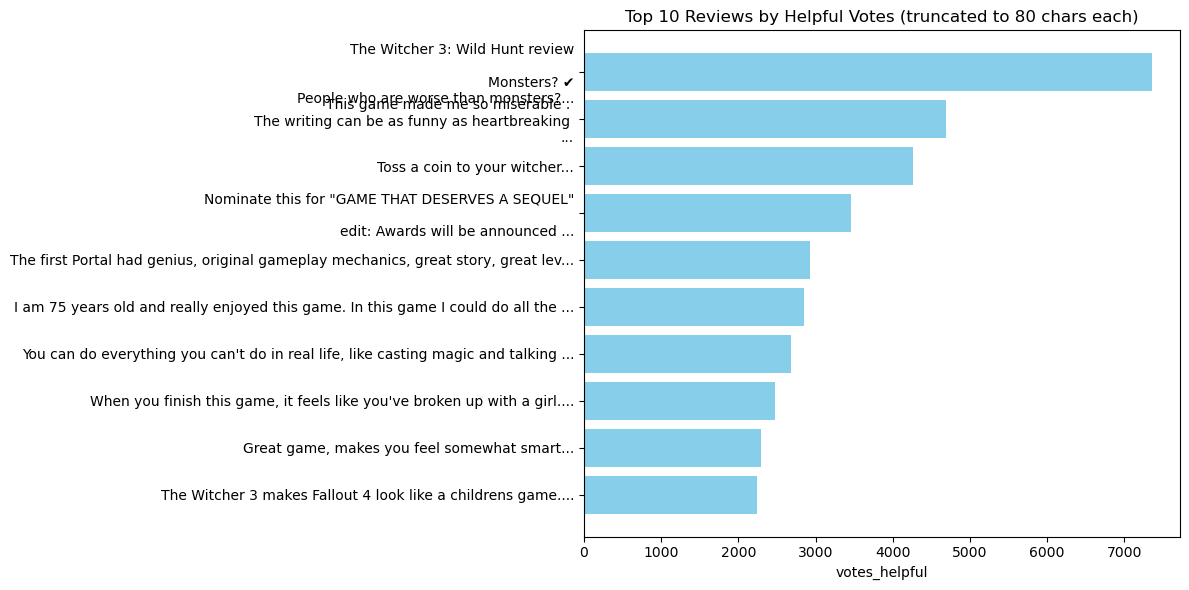

Review ID: 32479482 | votes_helpful: 7352
The Witcher 3: Wild Hunt review

Monsters? ✔
People who are worse than monsters? ✔
Naked girls? ✔
More naked girls? ✔
Even more naked girls? ✔
Nude scenes? ✔
Superb voice acting? ✔
Mind-blowingly good storyline? ✔
An amazing 1st DLC, worth every penny? ✔
An even better 2nd DLC? ✔
5 Gigantic open world areas? ✔ (Sorry Skyrim Skellige alone is as big as you) 
Beautiful environment? ✔
New Game +? ✔
No micro transactions? ✔
Ubisoft? Hell no m8's
In depth & amazing characters? ✔
Unbelievably good atmosphere? ✔
Soundtrack that is beyond awesome? ✔
Base game GOTY 2015 + Blood and Wine GOTY 2016? ✔
800 awards? ✔ Sorry every other game ever made 
Prevented Fallout 4 getting GOTY? ✔
Not a single bad thing to say? ✔
RIP social life? ✔

Cons:
No NG ++

I have never played a game quite like The Witcher 3. You literally feel like you are Geralt, and you become connected to all the characters asif they really were your family.


Summary:

I would highly recom

In [8]:
# Plot the top 10 reviews with the highest votes_helpful
temp = df_eng.copy()
# Sort reviews by votes_helpful descending, take top 10
top_votes = temp.sort_values("votes_helpful", ascending=False).head(10)

# Plot the review text and number of helpful votes for each of the top 10
plt.figure(figsize=(12, 6))
plt.barh(range(10), top_votes["votes_helpful"][::-1], color='skyblue')
plt.yticks(range(10), top_votes["review"][::-1].str.slice(0, 80) + "...", fontsize=10)
plt.xlabel("votes_helpful")
plt.title("Top 10 Reviews by Helpful Votes (truncated to 80 chars each)")
plt.tight_layout()
plt.show()

# Also print the review_id and number of helpful votes for clarity
for idx, row in top_votes.iterrows():
    print(f"Review ID: {row['review_id']} | votes_helpful: {row['votes_helpful']}")
    print(row["review"])
    print("-" * 70)

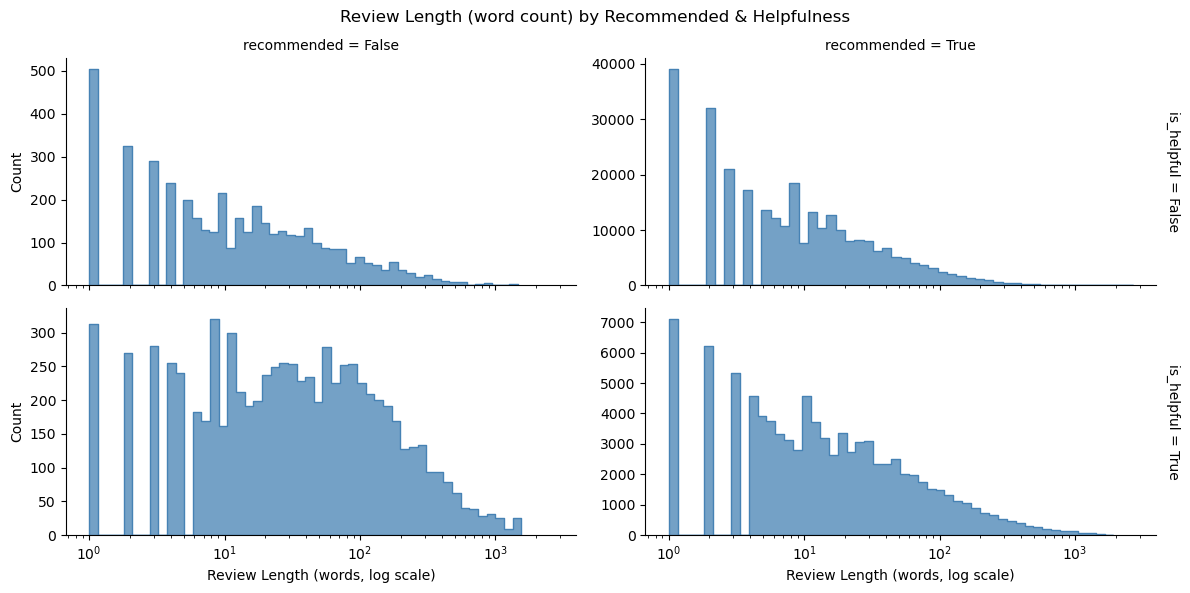

In [9]:
temp = df_eng.copy()
temp["review_word_count"] = temp["review"].fillna("").apply(lambda x: len(str(x).split()))
temp["is_helpful"] = temp["votes_helpful"] >= 1

# Visualize: Faceted histogram of review word count, split by recommended and helpful
g = sns.FacetGrid(
    temp,
    col="recommended",
    row="is_helpful",
    margin_titles=True,
    height=3,
    aspect=2,
    sharex=True,
    sharey=False,
)
g.map_dataframe(
    sns.histplot,
    "review_word_count",
    bins=50,
    color="steelblue",
    log_scale=True,
    element="step"
)
g.set_axis_labels("Review Length (words, log scale)", "Count")
g.set_titles(col_template="recommended = {col_name}", row_template="is_helpful = {row_name}")
g.tight_layout()
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Review Length (word count) by Recommended & Helpfulness")
plt.show()

In [10]:
import plotly.express as px

In [11]:
temp = df_eng.copy()
temp["review_word_count"] = temp["review"].fillna("").apply(lambda x: len(str(x).split()))
temp["is_helpful"] = temp["votes_helpful"] >= 1

temp["log10_word_count"] = np.log10(temp["review_word_count"].clip(lower=1))
fig = px.histogram(
    temp,
    x="log10_word_count",
    facet_row="is_helpful",
    facet_col="recommended",
    nbins=50,
    title="Review Length by Recommended & Helpfulness",
)
fig.update_xaxes(title_text="Review length (log10 words count)")
fig.update_yaxes(title_text="Count")

fig.show()